# FarrahAI - Notebook 4: Question Paper Prediction (Image Based)

This notebook now works directly from **question paper images** and does the following:
- OCR extraction from each uploaded paper image
- Parse structured details: maximum marks, marks distribution, total questions, questions to attempt
- Detect exam type (internal or external) and estimate credit alignment using your rule (`25 marks per credit`, `40% internal`, `60% external`)
- Map questions to topics using syllabus + trained topic classifier
- Build teacher profile from past papers
- Generate a predicted sample paper blueprint

Notes:
- This pipeline is designed for small history too (1-2 paper images)
- You can provide syllabus per uploaded paper in config below


In [1]:
import sys
sys.path.insert(0, '..')

import re
import json
import pickle
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from modules.ocr import extract_text
from modules.teacher_profile import (
    load_teacher_db,
    save_teacher_db,
    add_paper_to_teacher,
    get_teacher_summary,
    get_top_topics,
)
from modules.predictor import generate_sample_paper, format_paper_output
from modules.ollama_chat import chat, is_ollama_running

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists() and (PROJECT_ROOT.parent / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

print('Ready')
print('PROJECT_ROOT =', PROJECT_ROOT)

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)


Ready
PROJECT_ROOT = /home/harsh/Desktop/CUK/FarrahAI


## Step 1: Helpers - OCR parsing, exam metadata, topic mapping


In [2]:
WORD_TO_NUM = {
    'one': 1, 'two': 2, 'three': 3, 'four': 4, 'five': 5,
    'six': 6, 'seven': 7, 'eight': 8, 'nine': 9, 'ten': 10,
    'eleven': 11, 'twelve': 12
}


def to_num(token):
    token = str(token).strip().lower()
    if token.isdigit():
        return int(token)
    return WORD_TO_NUM.get(token)


def normalize_spaces(text: str) -> str:
    return re.sub(r'\s+', ' ', str(text)).strip()


def sanitize_name(name: str) -> str:
    return re.sub(r'[^a-zA-Z0-9_.-]+', '_', str(name)).strip('_')


def convert_pdf_to_images(pdf_path: Path, out_dir: Path):
    out_dir.mkdir(parents=True, exist_ok=True)
    images = []
    try:
        import fitz
    except Exception as e:
        raise RuntimeError(f'PyMuPDF (fitz) required for PDF input. Error: {e}')

    doc = fitz.open(str(pdf_path))
    base = sanitize_name(pdf_path.stem)
    for i in range(len(doc)):
        page = doc.load_page(i)
        pix = page.get_pixmap(dpi=250)
        out = out_dir / f"{base}_page_{i+1:03d}.png"
        pix.save(str(out))
        images.append(out)
    return images


def canonical_paper_id(source_name: str):
    stem = Path(source_name).stem
    stem = re.sub(r'_page_\d+$', '', stem, flags=re.IGNORECASE)
    stem = re.sub(r'[_-](?:front|back)$', '', stem, flags=re.IGNORECASE)
    stem = re.sub(r'[_-](\d+)$', '', stem)
    return stem


def expand_paper_inputs(paper_paths):
    expanded = []
    tmp_dir = PROJECT_ROOT / 'data' / 'processed' / 'question_paper_analysis' / 'pdf_pages'

    for p in paper_paths:
        p = Path(p)
        if not p.exists():
            continue
        suf = p.suffix.lower()
        if suf in {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}:
            expanded.append({'paper_source': p.name, 'paper_id': canonical_paper_id(p.name), 'image_path': p, 'page_no': 1})
        elif suf == '.pdf':
            pages = convert_pdf_to_images(p, tmp_dir)
            pid = canonical_paper_id(p.name)
            for idx, img in enumerate(pages, start=1):
                expanded.append({'paper_source': p.name, 'paper_id': pid, 'image_path': img, 'page_no': idx})

    return expanded


def extract_text_for_paper_image(image_path: Path, engine='tesseract'):
    if engine == 'tesseract':
        try:
            import pytesseract
            from PIL import Image
            img = Image.open(str(image_path))
            text = pytesseract.image_to_string(img, config='--oem 3 --psm 6')
            data = pytesseract.image_to_data(img, output_type=pytesseract.Output.DICT)
            confs = []
            for c, w in zip(data.get('conf', []), data.get('text', [])):
                try:
                    cc = float(c)
                except Exception:
                    continue
                if cc >= 0 and str(w).strip():
                    confs.append(cc)
            avg = (sum(confs) / len(confs) / 100.0) if confs else 0.0
            return {'text': text, 'confidence': round(avg, 4), 'engine': 'tesseract'}
        except Exception:
            return extract_text(str(image_path), engine='tesseract')
    return extract_text(str(image_path), engine=engine)


def parse_max_marks(full_text: str):
    t = full_text.lower()
    patterns = [
        r'(?:maximum|max)\s*[\.:-]?\s*marks\s*[:\-]?\s*(\d{1,3})',
        r'total\s*[\.:-]?\s*marks\s*[:\-]?\s*(\d{1,3})',
        r'\bmax\.\s*marks\s*[:\-]?\s*(\d{1,3})',
        r'\bmm\s*[:\-]?\s*(\d{1,3})',
    ]
    for pat in patterns:
        m = re.search(pat, t)
        if m:
            return int(m.group(1))
    return None


def parse_questions_to_attempt(full_text: str):
    t = full_text.lower()
    pats = [
        r'(?:attempt|answer)\s+any\s+(\w+)',
        r'(?:attempt|answer)\s+(\w+)\s+questions?',
        r'any\s+(\w+)\s+questions?',
    ]
    for pat in pats:
        m = re.search(pat, t)
        if m:
            return to_num(m.group(1))
    return None


def detect_exam_type(full_text: str, hint_type=None):
    if hint_type:
        return str(hint_type).lower()
    t = full_text.lower()
    if any(k in t for k in ['end semester', 'end-semester', 'endsem', 'external']):
        return 'external'
    if any(k in t for k in ['internal', 'mid term', 'midterm', 'sessional']):
        return 'internal'
    return 'unknown'


def infer_credits(max_marks, exam_type, hint_credits=None):
    if hint_credits:
        return int(hint_credits)
    if max_marks is None:
        return None
    if exam_type == 'internal':
        c = round(max_marks / 10)
    elif exam_type == 'external':
        c = round(max_marks / 15)
    else:
        c = round(max_marks / 25)
    return max(c, 1)


def credit_mark_scheme(credits):
    if credits is None:
        return {'total': None, 'internal': None, 'external': None}
    total = int(credits) * 25
    internal = int(round(total * 0.4))
    external = total - internal
    return {'total': total, 'internal': internal, 'external': external}


def parse_question_blocks(full_text: str):
    txt = full_text.replace('\r', '\n')
    txt = re.sub(r'(?i)(?:^|\s)q\s*(\d{1,2})\s*([\).:\-])', r'\nQ\1\2', txt)
    txt = re.sub(r'(?m)^\s*(\d{1,2})\s*([\).:\-])', r'Q\1\2', txt)

    pat = re.compile(r'(?is)\bQ\s*(\d{1,2})\s*[\).:\-]?\s*(.+?)(?=(?:\n?\s*Q\s*\d{1,2}\s*[\).:\-])|$)')
    found = []
    for m in pat.finditer(txt):
        q_no = int(m.group(1))
        q_text = normalize_spaces(m.group(2))
        if len(q_text) >= 12:
            found.append({'q_no': q_no, 'text': q_text})

    lines = [normalize_spaces(x) for x in txt.splitlines() if normalize_spaces(x)]

    # Recover missed question lines when OCR drops Q-number marker (common in scanned papers)
    loose_candidates = []
    loose_pat = re.compile(r'^[~._\-–—]+\s*[A-Za-z]')
    for ln in lines:
        if ln.startswith('['):
            continue
        if loose_pat.match(ln):
            clean = re.sub(r'^[~._\-–—]+\s*', '', ln).strip()
            kw = ['explain', 'define', 'what', 'how', 'compare', 'differentiate', 'discuss']
            if len(clean.split()) >= 6 and ('?' in clean or any(k in clean.lower() for k in kw)):
                loose_candidates.append(clean)

    if found:
        best = {}
        for q in found:
            qno = q['q_no']
            if qno not in best or len(q['text']) > len(best[qno]['text']):
                best[qno] = q

        ordered = [best[k] for k in sorted(best)]
        used = set(best.keys())
        max_q = max(used) if used else 0

        # Fill obvious numbering gaps with loose candidates
        missing = [i for i in range(1, max_q + 1) if i not in used]
        for miss_no, cand in zip(missing, loose_candidates):
            ordered.append({'q_no': miss_no, 'text': cand})

        ordered = sorted(ordered, key=lambda x: x['q_no'])
        return ordered

    # Fallback line parser
    out = []
    cur = None
    q_pat = re.compile(r'^(?:q\s*)?(\d{1,2})\s*[\).:\-]\s*(.*)$', re.IGNORECASE)
    for ln in lines:
        mm = q_pat.match(ln)
        if mm:
            if cur:
                out.append(cur)
            cur = {'q_no': int(mm.group(1)), 'text': mm.group(2).strip() or ln}
        else:
            if cur:
                cur['text'] = normalize_spaces(cur['text'] + ' ' + ln)
    if cur:
        out.append(cur)
    return out


def parse_question_marks(q_text: str):
    t = q_text.lower()
    pats = [
        r'(\d{1,2})\s*marks?\b',
        r'\[(\d{1,2})\]',
        r'\((\d{1,2})\)\s*$',
    ]
    for pat in pats:
        m = re.search(pat, t)
        if m:
            return int(m.group(1))
    return None


def infer_marks_per_question(full_text: str, total_questions: int, max_marks: int, questions_to_attempt: int):
    t = full_text.lower()
    pats = [
        r'(\d{1,2})\s*marks?\s*each',
        r'each\s+question\s+carries\s*(\d{1,2})',
        r'carry\s*(\d{1,2})\s*marks?\s*each',
    ]
    for pat in pats:
        m = re.search(pat, t)
        if m:
            return int(m.group(1))

    if max_marks and questions_to_attempt and max_marks % questions_to_attempt == 0:
        return int(max_marks / questions_to_attempt)
    if max_marks and total_questions and max_marks % total_questions == 0:
        return int(max_marks / total_questions)
    return None


def question_style(q_text: str):
    t = q_text.lower()
    if 'compare' in t or 'differentiate' in t:
        return 'compare'
    if 'derive' in t or 'proof' in t:
        return 'derive'
    if 'explain' in t or 'discuss' in t:
        return 'explain'
    if 'define' in t or 'what is' in t:
        return 'define'
    if 'solve' in t or 'calculate' in t or 'find' in t:
        return 'numerical'
    if 'short note' in t:
        return 'short_note'
    return 'general'


def tokenize(s: str):
    return set(re.findall(r'[a-z]+', str(s).lower()))


def choose_topic_by_overlap(question: str, candidates: list):
    q_tokens = tokenize(question)
    if not q_tokens or not candidates:
        return None
    best_topic = None
    best_score = 0
    for topic in candidates:
        t_tokens = tokenize(topic)
        if not t_tokens:
            continue
        score = len(q_tokens.intersection(t_tokens))
        if score > best_score:
            best_score = score
            best_topic = topic
    return best_topic if best_score > 0 else None


def load_topic_classifier_artifacts():
    model_path = PROJECT_ROOT / 'models' / 'topic_classifier_best.pkl'
    le_path = PROJECT_ROOT / 'models' / 'topic_label_encoder.pkl'
    vec_path = PROJECT_ROOT / 'models' / 'topic_tfidf_vectorizer.pkl'
    if model_path.exists() and le_path.exists() and vec_path.exists():
        model = pickle.loads(model_path.read_bytes())
        le = pickle.loads(le_path.read_bytes())
        vec = pickle.loads(vec_path.read_bytes())
        return model, le, vec
    return None, None, None


def classify_topic(question, model, le, vec):
    if model is None or le is None or vec is None:
        return None, None
    X = vec.transform([question])
    y_hat = model.predict(X)[0]
    topic = le.inverse_transform([y_hat])[0]
    conf = None
    if hasattr(model, 'predict_proba'):
        try:
            conf = float(model.predict_proba(X).max())
        except Exception:
            conf = None
    return topic, conf


def infer_syllabus_tag(file_name: str):
    n = str(file_name).lower()
    if 'internal1' in n or 'internal_1' in n or 'int1' in n:
        return 'internal1'
    if 'internal2' in n or 'internal_2' in n or 'int2' in n:
        return 'internal2'
    if 'endsem' in n or 'external' in n:
        return 'external'
    return 'general'


def generate_with_ollama(prompt: str, model: str = 'mistral'):
    if not is_ollama_running():
        return None, 'Ollama server not running'

    try:
        return chat(prompt=prompt, model=model), None
    except Exception as e:
        # Fallback for older Ollama builds that expose /api/generate but not /api/chat
        try:
            import requests
            r = requests.post(
                'http://localhost:11434/api/generate',
                json={'model': model, 'prompt': prompt, 'stream': False},
                timeout=180,
            )
            r.raise_for_status()
            data = r.json()
            out = data.get('response', '').strip()
            if out:
                return out, None
            return None, f'Empty response from /api/generate'
        except Exception as e2:
            return None, f'{e}; fallback failed: {e2}'


## Step 2: Configuration
Set image paths, syllabus per paper, and teacher metadata here.


In [3]:
TEACHER_NAME = 'Dr Rakesh Godi'
SUBJECT_CODE = 'AI_ML'
TEACHER_DB_PATH = str(PROJECT_ROOT / 'data' / 'teacher_profiles.json')
OCR_ENGINE = 'tesseract'
RESET_TEACHER_PROFILE_FOR_THIS_RUN = True

AUTO_DIR = PROJECT_ROOT / 'data' / 'question_papers'
AUTO_PAPER_FILES = sorted(
    [p for p in AUTO_DIR.glob('*') if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.pdf'}]
)
MANUAL_PAPER_FILES = []
PAPER_FILES = AUTO_PAPER_FILES if AUTO_PAPER_FILES else MANUAL_PAPER_FILES
if not PAPER_FILES:
    raise FileNotFoundError(f'No paper files found in: {AUTO_DIR}')

SYLLABUS_IMAGE_INTERNAL1 = PROJECT_ROOT / 'data' / 'knowledge_base' / 'AI_ML_2026_internal1.png'
SYLLABUS_IMAGE_INTERNAL2 = PROJECT_ROOT / 'data' / 'knowledge_base' / 'AI_ML_2026_internal2.png'

PAPER_HINTS = {
    'AIML_MNC_internal2_sample_questions.pdf': {'year': 2026, 'semester': 'even', 'exam_type': 'internal', 'credits': 4, 'syllabus_tag': 'internal2'},
    'AI_ML_Internal1_1.jpeg': {'year': 2026, 'semester': 'even', 'exam_type': 'internal', 'credits': 4, 'syllabus_tag': 'internal1'},
    'AI_ML_Internal1_2.jpeg': {'year': 2026, 'semester': 'even', 'exam_type': 'internal', 'credits': 4, 'syllabus_tag': 'internal1'},
}

OVERALL_SYLLABUS_TOPICS = [
    'Introduction to Artificial Intelligence','Future of Artificial Intelligence','Characteristics of Intelligent Agents','Typical Intelligent Agents',
    'Introduction to machine learning','Probability for ML and linear regression','Classification of machine learning problems','Types of AI and ML algorithms',
    'Supervised learning','Unsupervised learning','Reinforcement learning','Neural networks','Cost functions','Activation functions',
    'Optimization strategies','CNN','GNN','Decision trees','Scikit library','TensorFlow library','PyTorch library','Machine learning pipelines',
    'Natural language processing','Computer vision',
]

SYLLABUS_BY_TAG = {
    'internal1': [
        'Introduction to Artificial Intelligence','Future of Artificial Intelligence','Characteristics of Intelligent Agents','Typical Intelligent Agents',
        'Introduction to machine learning','Probability for ML and linear regression','Classification of machine learning problems','Types of AI and ML algorithms',
    ],
    'internal2': [
        'Supervised learning','Unsupervised learning','Reinforcement learning','Regression analysis','Regression algorithms','Classification',
        'Classification algorithms','Clustering','Ensemble methods','Neural networks','Cost functions','Activation functions',
        'Optimization strategies','CNN','GNN','Decision trees',
    ],
    'external': OVERALL_SYLLABUS_TOPICS,
    'general': OVERALL_SYLLABUS_TOPICS,
}

topic_csv = PROJECT_ROOT / 'data' / 'processed' / 'farrahai_topic_dataset_text_topic.csv'
if topic_csv.exists():
    df_topic = pd.read_csv(topic_csv)
    TOPIC_CANDIDATES = sorted(df_topic['topic'].dropna().astype(str).str.strip().unique().tolist())
else:
    TOPIC_CANDIDATES = OVERALL_SYLLABUS_TOPICS.copy()

print('Paper files:', [p.name for p in PAPER_FILES])
print('Has syllabus image internal1:', SYLLABUS_IMAGE_INTERNAL1.exists())
print('Has syllabus image internal2:', SYLLABUS_IMAGE_INTERNAL2.exists())
print('Topic candidates loaded:', len(TOPIC_CANDIDATES))


Paper files: ['AIML_MNC_internal2_sample_questions.pdf', 'AI_ML_Internal1_1.jpeg', 'AI_ML_Internal1_2.jpeg']
Has syllabus image internal1: True
Has syllabus image internal2: True
Topic candidates loaded: 14


## Step 3: OCR each paper image and parse structured details


In [4]:
model_topic, le_topic, vec_topic = load_topic_classifier_artifacts()
if model_topic is None:
    print('Topic classifier artifacts not found in ../models. Using overlap mapping only.')
else:
    print('Loaded topic classifier artifacts from ../models.')

expanded_inputs = expand_paper_inputs(PAPER_FILES)
if not expanded_inputs:
    raise ValueError('No supported image/pdf inputs found after expansion.')

page_rows = []
for item in expanded_inputs:
    img_path = Path(item['image_path'])
    ocr_res = extract_text_for_paper_image(img_path, engine=OCR_ENGINE)
    page_rows.append({
        'paper_source': item['paper_source'],
        'paper_id': item['paper_id'],
        'page_no': item['page_no'],
        'page_file': img_path.name,
        'ocr_text': ocr_res.get('text', ''),
        'ocr_confidence': ocr_res.get('confidence', 0.0),
    })

pages_df = pd.DataFrame(page_rows).sort_values(['paper_id', 'page_no']).reset_index(drop=True)

paper_records = []
question_rows = []

for paper_id, grp in pages_df.groupby('paper_id', sort=False):
    source_names = grp['paper_source'].unique().tolist()
    source_key = source_names[0]

    hint = PAPER_HINTS.get(source_key, {})
    if not hint:
        for sn in source_names:
            if sn in PAPER_HINTS:
                hint = PAPER_HINTS[sn]
                break

    syllabus_tag = hint.get('syllabus_tag') or infer_syllabus_tag(source_key)
    syllabus_topics = SYLLABUS_BY_TAG.get(syllabus_tag, OVERALL_SYLLABUS_TOPICS)

    full_text = '\n'.join(grp['ocr_text'].fillna('').astype(str).tolist())
    page_conf = float(grp['ocr_confidence'].mean()) if len(grp) else 0.0

    max_marks = parse_max_marks(full_text)
    q_attempt = parse_questions_to_attempt(full_text)
    exam_type = detect_exam_type(full_text, hint_type=hint.get('exam_type'))
    credits = infer_credits(max_marks, exam_type, hint_credits=hint.get('credits'))
    scheme = credit_mark_scheme(credits)

    questions = parse_question_blocks(full_text)
    total_questions = len(questions)
    inferred_mark_each = infer_marks_per_question(full_text, total_questions, max_marks, q_attempt)
    if inferred_mark_each is None and exam_type == 'internal' and scheme.get('internal') and q_attempt:
        if int(scheme['internal']) % int(q_attempt) == 0:
            inferred_mark_each = int(int(scheme['internal']) / int(q_attempt))

    marks_list = []
    topic_counter = Counter()
    style_counter = Counter()

    for q in questions:
        q_text = q['text']
        q_marks = parse_question_marks(q_text)
        if q_marks is None and inferred_mark_each is not None:
            q_marks = inferred_mark_each

        q_style = question_style(q_text)
        pred_topic, pred_conf = classify_topic(q_text, model_topic, le_topic, vec_topic)
        overlap_topic = choose_topic_by_overlap(q_text, syllabus_topics)
        final_topic = overlap_topic or pred_topic or choose_topic_by_overlap(q_text, TOPIC_CANDIDATES) or 'unknown'

        if q_marks is not None:
            marks_list.append(int(q_marks))
        topic_counter[final_topic] += 1
        style_counter[q_style] += 1

        question_rows.append({
            'paper_id': paper_id,
            'paper_source': source_key,
            'q_no': q['q_no'],
            'question': q_text,
            'marks': int(q_marks) if q_marks is not None else None,
            'style': q_style,
            'topic': final_topic,
            'topic_model_prediction': pred_topic,
            'topic_model_confidence': pred_conf,
            'syllabus_tag': syllabus_tag,
        })

    marks_distribution = dict(Counter([m for m in marks_list if int(m) > 0]))

    asked_topics = set([k for k in topic_counter if k != 'unknown'])
    syllabus_set = set(syllabus_topics)
    covered = asked_topics.intersection(syllabus_set)
    coverage = (len(covered) / len(syllabus_set)) if syllabus_set else None

    paper_records.append({
        'paper_id': paper_id,
        'paper_source': source_key,
        'source_files': ', '.join(source_names),
        'page_count': int(len(grp)),
        'year': hint.get('year'),
        'semester': hint.get('semester', 'unknown'),
        'exam_type': exam_type,
        'credits': credits,
        'expected_total_marks': scheme['total'],
        'expected_internal_marks': scheme['internal'],
        'expected_external_marks': scheme['external'],
        'detected_max_marks': max_marks,
        'detected_questions_to_attempt': q_attempt,
        'detected_total_questions': total_questions,
        'inferred_marks_each': inferred_mark_each,
        'ocr_confidence': round(page_conf, 4),
        'marks_distribution': json.dumps(marks_distribution),
        'top_topic': topic_counter.most_common(1)[0][0] if topic_counter else 'unknown',
        'top_style': style_counter.most_common(1)[0][0] if style_counter else 'unknown',
        'syllabus_tag': syllabus_tag,
        'syllabus_topics_count': len(syllabus_set),
        'syllabus_topics_covered': len(covered),
        'syllabus_coverage_ratio': coverage,
        'ocr_text': full_text,
    })

papers_df = pd.DataFrame(paper_records)
questions_df = pd.DataFrame(question_rows)

out_dir = PROJECT_ROOT / 'data' / 'processed' / 'question_paper_analysis'
out_dir.mkdir(parents=True, exist_ok=True)

pages_df.to_csv(out_dir / 'parsed_pages_raw_ocr.csv', index=False)
papers_df.to_csv(out_dir / 'parsed_papers_summary.csv', index=False)
questions_df.to_csv(out_dir / 'parsed_questions.csv', index=False)

print('Saved:', out_dir / 'parsed_pages_raw_ocr.csv')
print('Saved:', out_dir / 'parsed_papers_summary.csv')
print('Saved:', out_dir / 'parsed_questions.csv')
display(papers_df)


Loaded topic classifier artifacts from ../models.
Saved: /home/harsh/Desktop/CUK/FarrahAI/data/processed/question_paper_analysis/parsed_pages_raw_ocr.csv
Saved: /home/harsh/Desktop/CUK/FarrahAI/data/processed/question_paper_analysis/parsed_papers_summary.csv
Saved: /home/harsh/Desktop/CUK/FarrahAI/data/processed/question_paper_analysis/parsed_questions.csv


,paper_id,paper_source,source_files,page_count,year,semester,exam_type,credits,expected_total_marks,expected_internal_marks,...,inferred_marks_each,ocr_confidence,marks_distribution,top_topic,top_style,syllabus_tag,syllabus_topics_count,syllabus_topics_covered,syllabus_coverage_ratio,ocr_text
0,AIML_MNC_internal2_sample_questions,AIML_MNC_internal2_sample_questions.pdf,AIML_MNC_internal2_sample_questions.pdf,3,2026,even,internal,4,100,40,...,None,0.9497,{},Supervised learning,explain,internal2,16,5,0.3125,MACHINE LEARNING\nTopics: Regression Models | ...
1,AI_ML_Internal1,AI_ML_Internal1_1.jpeg,"AI_ML_Internal1_1.jpeg, AI_ML_Internal1_2.jpeg",2,2026,even,internal,4,100,40,...,None,0.9024,{},Introduction to Artificial Intelligence,explain,internal1,8,4,0.5000,"OF KARNATAKA (""| |\n(Established by an Act of ..."


## Step 4: Build/update teacher profile from parsed papers


In [5]:
db = load_teacher_db(TEACHER_DB_PATH)

if RESET_TEACHER_PROFILE_FOR_THIS_RUN:
    db.pop(TEACHER_NAME, None)

if questions_df.empty or papers_df.empty:
    raise ValueError('No parsed paper/question data found. Check OCR and input files.')

for pid in papers_df['paper_id'].dropna().unique().tolist():
    p = papers_df[papers_df['paper_id'] == pid].iloc[0]
    qdf = questions_df[questions_df['paper_id'] == pid].copy()

    inferred_each = int(p['inferred_marks_each']) if pd.notna(p['inferred_marks_each']) else None
    known_marks = [int(x) for x in qdf['marks'].dropna().tolist() if int(x) > 0]
    source_name = str(p['paper_source']).lower() if pd.notna(p['paper_source']) else ''
    is_sample_paper = 'sample' in source_name

    if inferred_each is not None and inferred_each > 0:
        fallback_mark = inferred_each
    elif known_marks:
        fallback_mark = int(round(np.median(known_marks)))
    elif is_sample_paper:
        # sample papers often have no marking scheme; don't force fake marks into profile
        fallback_mark = None
    else:
        fallback_mark = 5

    topics_list = []
    for _, q in qdf.iterrows():
        raw_m = int(q['marks']) if pd.notna(q['marks']) else 0
        m = raw_m if raw_m > 0 else fallback_mark
        topics_list.append({'name': str(q['topic']), 'marks': m, 'question': str(q['question'])})

    paper_payload = {
        'subject': SUBJECT_CODE,
        'paper_type': str(p['exam_type']) if pd.notna(p['exam_type']) else 'unknown',
        'year': int(p['year']) if pd.notna(p['year']) else 2026,
        'semester': str(p['semester']) if pd.notna(p['semester']) else 'unknown',
        'total_marks': int(p['detected_max_marks']) if pd.notna(p['detected_max_marks']) else 0,
        'topics': topics_list,
    }
    add_paper_to_teacher(db, TEACHER_NAME, paper_payload)

save_teacher_db(db, TEACHER_DB_PATH)
print(get_teacher_summary(TEACHER_NAME, db))


Teacher: Dr Rakesh Godi
Subjects: AI_ML
Papers analyzed: 2
Last updated: 2026-04-15T21:40:41.661158

Top 5 topics by frequency:
  1. supervised learning (asked 10 time(s))
  2. neural networks (asked 8 time(s))
  3. unsupervised learning (asked 3 time(s))
  4. ensemble methods (asked 3 time(s))
  5. introduction to artificial intelligence (asked 3 time(s))

Marks distribution:
  5 marks: 6 question(s)


## Step 5: Analysis - what this teacher asks most


Top asked topics:


,topic,count
0,Supervised learning,10
1,Neural networks,8
2,Unsupervised learning,3
3,Ensemble methods,3
4,Introduction to Artificial Intelligence,3
5,Reinforcement learning,1
6,Characteristics of Intelligent Agents,1
7,Introduction to machine learning,1
8,Classification of machine learning problems,1


Question style distribution:


,style,count
0,explain,22
1,define,6
2,compare,3


Marks distribution:


,marks,count
0,5,6


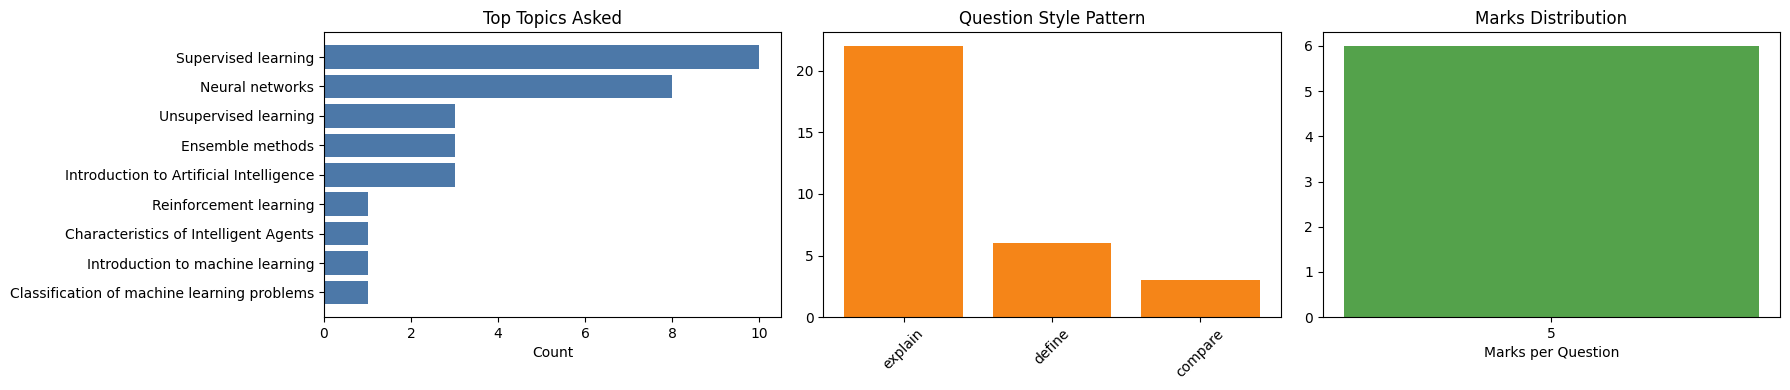

In [6]:
topic_freq = questions_df['topic'].value_counts().reset_index()
topic_freq.columns = ['topic', 'count']

style_freq = questions_df['style'].value_counts().reset_index()
style_freq.columns = ['style', 'count']

marks_series = questions_df['marks'].dropna()
if len(marks_series) > 0:
    marks_freq = marks_series.astype(int).value_counts().sort_index().reset_index()
    marks_freq.columns = ['marks', 'count']
else:
    marks_freq = pd.DataFrame(columns=['marks', 'count'])


if marks_freq.empty and TEACHER_NAME in db:
    md = db.get(TEACHER_NAME, {}).get('marks_distribution', {})
    rows = []
    for k, v in md.items():
        try:
            kk = int(k)
            if kk > 0:
                rows.append({'marks': kk, 'count': int(v)})
        except Exception:
            continue
    if rows:
        marks_freq = pd.DataFrame(rows).sort_values('marks').reset_index(drop=True)

print('Top asked topics:')
display(topic_freq.head(15))

print('Question style distribution:')
display(style_freq)

print('Marks distribution:')
display(marks_freq)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].barh(topic_freq['topic'].head(10)[::-1], topic_freq['count'].head(10)[::-1], color='#4C78A8')
axes[0].set_title('Top Topics Asked')
axes[0].set_xlabel('Count')

axes[1].bar(style_freq['style'], style_freq['count'], color='#F58518')
axes[1].set_title('Question Style Pattern')
axes[1].tick_params(axis='x', rotation=45)

if not marks_freq.empty:
    axes[2].bar(marks_freq['marks'].astype(str), marks_freq['count'], color='#54A24B')
axes[2].set_title('Marks Distribution')
axes[2].set_xlabel('Marks per Question')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'paper_pattern_analysis.png', dpi=150)
plt.show()


## Step 6: Generate sample predicted paper blueprint


In [7]:
TARGET_EXAM_TYPE = 'internal'   # internal | external
TARGET_CREDITS = 4

if TEACHER_NAME in db:
    md = db[TEACHER_NAME].get('marks_distribution', {})
    clean_md = {}
    for k, v in md.items():
        try:
            kk = int(k)
            if kk > 0:
                clean_md[str(kk)] = int(v)
        except Exception:
            continue
    if not clean_md:
        clean_md = {'5': 1, '10': 1}
    db[TEACHER_NAME]['marks_distribution'] = clean_md

paper_mask = papers_df['exam_type'].astype(str).str.lower() == TARGET_EXAM_TYPE
if paper_mask.any():
    # Prefer real papers for format inference; use sample papers mainly for topic/style learning.
    real_mask = paper_mask & (~papers_df['paper_source'].astype(str).str.lower().str.contains('sample'))
    ref_pool = papers_df[real_mask] if real_mask.any() else papers_df[paper_mask]
    ref = ref_pool.iloc[0]

    total_q = int(ref['detected_total_questions']) if pd.notna(ref['detected_total_questions']) and int(ref['detected_total_questions']) > 0 else 8
    if TARGET_EXAM_TYPE == 'internal' and total_q < 8:
        total_q = 8

    to_attempt = int(ref['detected_questions_to_attempt']) if pd.notna(ref['detected_questions_to_attempt']) and int(ref['detected_questions_to_attempt']) > 0 else None
    if to_attempt is None:
        to_attempt = 5 if TARGET_EXAM_TYPE == 'internal' else max(5, int(round(total_q * 0.6)))

    marks_each = int(ref['inferred_marks_each']) if pd.notna(ref['inferred_marks_each']) and int(ref['inferred_marks_each']) > 0 else None
    if marks_each is None:
        max_marks_ref = int(ref['detected_max_marks']) if pd.notna(ref['detected_max_marks']) else None
        if max_marks_ref and to_attempt and max_marks_ref % to_attempt == 0:
            marks_each = int(max_marks_ref / to_attempt)
        else:
            marks_each = 5
else:
    total_q, to_attempt, marks_each = 8, 5, 5

target_scheme = credit_mark_scheme(TARGET_CREDITS)
target_marks = target_scheme['internal'] if TARGET_EXAM_TYPE == 'internal' else target_scheme['external']

pred_paper = generate_sample_paper(
    teacher_name=TEACHER_NAME,
    subject=SUBJECT_CODE,
    teacher_db=db,
    total_marks=target_marks,
    paper_type=TARGET_EXAM_TYPE,
)

print(format_paper_output(pred_paper))

top_topics_for_prompt = [x['topic'] for x in get_top_topics(TEACHER_NAME, db, top_n=max(total_q, 10))]
style_order = style_freq.sort_values('count', ascending=False)['style'].tolist() if 'style_freq' in globals() else ['explain', 'compare', 'define']
style_text = ', '.join(style_order[:5]) if style_order else 'explain, compare, define'

prompt = f'''You are creating an academic question paper.
Teacher: {TEACHER_NAME}
Subject: {SUBJECT_CODE}
Exam type: {TARGET_EXAM_TYPE}
Paper rule: Total questions = {total_q}, student must attempt any {to_attempt}, each question = {marks_each} marks.
Total marks to attempt = {to_attempt * marks_each}.
Preferred topics (historical priority): {', '.join(top_topics_for_prompt[:12])}
Preferred question styles by teacher pattern: {style_text}

Generate exactly {total_q} clear, exam-quality questions.
Keep difficulty moderate and syllabus-aligned.
Output plain text in this format only:
Q1. ...
Q2. ...
...
Q{total_q}. ...
'''

ollama_question_paper, ollama_err = generate_with_ollama(prompt=prompt, model='mistral:7b-instruct-q4_0')
if ollama_question_paper:
    print('\n--- Ollama Generated Question Paper ---\n')
    print(ollama_question_paper)
else:
    print('Ollama generation failed:', ollama_err)

pred_out = PROJECT_ROOT / 'outputs' / 'predicted_paper_AI_ML_Dr_Rakesh_Godi.json'
pred_out.write_text(json.dumps(pred_paper, indent=2), encoding='utf-8')
print('Saved:', pred_out)

if ollama_question_paper:
    txt_out = PROJECT_ROOT / 'outputs' / 'predicted_paper_AI_ML_Dr_Rakesh_Godi_ollama.txt'
    txt_out.write_text(ollama_question_paper, encoding='utf-8')
    print('Saved:', txt_out)


╔══════════════════════════════════════════════════╗
  FARRAHAI PREDICTED SAMPLE PAPER
  Subject:    AI_ML
  Teacher:    Dr Rakesh Godi
  Paper Type: internal
  Total Marks:40
╚══════════════════════════════════════════════════╝

⚠ This is a predicted sample paper based on historical topic analysis. It is not a guarantee of the actual exam content.

── Section (5 marks each) ──────────────────────────
  Q1. [supervised learning]  (5 marks)
  Q2. [neural networks]  (5 marks)
  Q3. [unsupervised learning]  (5 marks)
  Q4. [ensemble methods]  (5 marks)
  Q5. [introduction to artificial intelligence]  (5 marks)
  Q6. [reinforcement learning]  (5 marks)


--- Ollama Generated Question Paper ---

Q1. Define supervised learning and explain its importance in artificial intelligence.
Q2. Compare the difference between a neural network and a decision tree in terms of their architecture and performance.
Q3. What is clustering, and what are some common techniques used for unsupervised learning?
Q4

## Step 7: Export concise teacher-profile report for presentation


In [8]:
profile_report = {
    'teacher_name': TEACHER_NAME,
    'subject': SUBJECT_CODE,
    'papers_analyzed': int(len(papers_df)),
    'total_questions_parsed': int(len(questions_df)),
    'top_topics': topic_freq.head(10).to_dict(orient='records'),
    'marks_distribution': marks_freq.to_dict(orient='records'),
    'style_distribution': style_freq.to_dict(orient='records'),
    'paper_level_summary': papers_df.drop(columns=['ocr_text']).to_dict(orient='records'),
}

report_out = PROJECT_ROOT / 'outputs' / 'teacher_profile_report_dr_rakesh_godi.json'
report_out.write_text(json.dumps(profile_report, indent=2), encoding='utf-8')
print('Saved:', report_out)


Saved: /home/harsh/Desktop/CUK/FarrahAI/outputs/teacher_profile_report_dr_rakesh_godi.json
